In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import SpectralClustering

# Bank Reserves

In [3]:
br_pca = pd.read_csv('extracted_features/bank_reserves_pca_standardized.csv')
br_pca = br_pca.drop('Unnamed: 0', axis=1)

br_dae = pd.read_csv('extracted_features/bank_reserves_dae.csv', header=None)
br_daep = pd.read_csv('extracted_features/0_DAE_5_2_2048_linear.csv', header=None)

## Kmeans

In [5]:
br_pca_kmeans = KMeans(n_clusters=7, random_state=0, n_init="auto").fit(br_pca).labels_

In [6]:
br_dae_kmeans = KMeans(n_clusters=7, random_state=0, n_init="auto").fit(br_dae).labels_

In [7]:
br_daep_kmeans = KMeans(n_clusters=7, random_state=0, n_init="auto").fit(br_daep).labels_

## Agglomerative Clustering

In [9]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=7, metric='euclidean', linkage='ward')
labels_sub = hierarchical_cluster.fit_predict(br_pca[1:10000])
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(br_pca[1:10000], labels_sub)
br_pca_agglom = neigh.predict(br_pca)

In [10]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=7, metric='euclidean', linkage='ward')
labels_sub = hierarchical_cluster.fit_predict(br_dae[1:10000])
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(br_dae[1:10000], labels_sub)
br_dae_agglom = neigh.predict(br_dae)

In [11]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=7, metric='euclidean', linkage='ward')
labels_sub = hierarchical_cluster.fit_predict(br_daep[1:10000])
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(br_daep[1:10000], labels_sub)
br_daep_agglom = neigh.predict(br_daep)

## Spectral Clustering

In [13]:
spectral_labs =SpectralClustering(n_clusters=7, assign_labels='discretize', affinity='nearest_neighbors', random_state=0).fit(br_pca[1:10000]).labels_
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(br_pca[1:10000], spectral_labs)
br_pca_spectral = neigh.predict(br_pca)

C:\Users\Maria\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [14]:
spectral_labs =SpectralClustering(n_clusters=7, assign_labels='discretize', affinity='nearest_neighbors', random_state=0).fit(br_dae[1:10000]).labels_
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(br_dae[1:10000], spectral_labs)
br_dae_spectral = neigh.predict(br_dae)

In [15]:
spectral_labs =SpectralClustering(n_clusters=7, assign_labels='discretize', affinity='nearest_neighbors', random_state=0).fit(br_daep[1:10000]).labels_
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(br_daep[1:10000], spectral_labs)
br_daep_spectral = neigh.predict(br_daep)

## Concat results

In [17]:
br_results = np.vstack((br_pca_kmeans, br_dae_kmeans, br_daep_kmeans, 
                        br_pca_agglom, br_dae_agglom, br_daep_agglom, 
                        br_pca_spectral, br_dae_spectral, br_daep_spectral))
br_results_df = pd.DataFrame(br_results)
br_results_df.index = ["PCA_KMeans", "DAE_KMeans", "DAEP_KMeans", 
    "PCA_Agglom", "DAE_Agglom", "DAEP_Agglom", 
    "PCA_Spectral", "DAE_Spectral", "DAEP_Spectral"]

In [18]:
br_results_df.to_csv("bank_reserves_daep_results.csv", )

In [19]:
br_results_df

,0,1,2,3,4,5,6,7,8,9,...,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999
PCA_KMeans,6,6,6,3,2,6,6,1,6,6,...,3,2,2,1,6,5,4,0,2,6
DAE_KMeans,5,5,2,4,0,2,2,4,5,2,...,4,0,6,1,2,1,1,3,6,5
DAEP_KMeans,2,2,2,1,0,2,2,1,2,2,...,1,0,0,1,2,1,1,3,0,4
PCA_Agglom,4,4,4,0,3,4,4,0,4,4,...,0,3,6,0,4,1,5,3,6,4
DAE_Agglom,1,1,5,3,4,5,1,3,1,5,...,3,4,2,3,1,6,6,0,2,1
DAEP_Agglom,2,2,4,3,1,4,2,6,2,4,...,6,1,5,6,4,6,6,0,5,2
PCA_Spectral,3,3,0,5,4,0,3,5,3,0,...,5,4,1,5,3,2,6,4,1,1
DAE_Spectral,4,4,0,1,5,0,4,1,4,0,...,1,6,5,1,4,3,3,6,5,5
DAEP_Spectral,4,4,0,1,3,0,4,6,4,0,...,1,3,3,6,4,6,6,5,2,2


# Epstein Civil Violence

In [21]:
ecv_pca = pd.read_csv('extracted_features/epstein_pca_standardized.csv')
ecv_pca = ecv_pca.drop('Unnamed: 0', axis=1)
ecv_dae = pd.read_csv('extracted_features/epstein_dae.csv', header=None)
ecv_daep = pd.read_csv('extracted_features/1_DAE_5_3_2048_linear.csv', header=None)

## Kmeans

In [23]:
ecv_pca_kmeans = KMeans(n_clusters=8, random_state=0, n_init="auto").fit(ecv_pca).labels_
ecv_dae_kmeans = KMeans(n_clusters=8, random_state=0, n_init="auto").fit(ecv_dae).labels_
ecv_daep_kmeans = KMeans(n_clusters=8, random_state=0, n_init="auto").fit(ecv_daep).labels_

## Agglomerative 

In [25]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=8, metric='euclidean', linkage='ward')
labels_sub = hierarchical_cluster.fit_predict(ecv_pca[1:10000])
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ecv_pca[1:10000], labels_sub)
ecv_pca_agglom = neigh.predict(ecv_pca)

In [26]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=8, metric='euclidean', linkage='ward')
labels_sub = hierarchical_cluster.fit_predict(ecv_dae[1:10000])
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ecv_dae[1:10000], labels_sub)
ecv_dae_agglom = neigh.predict(ecv_dae)

In [27]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=8, metric='euclidean', linkage='ward')
labels_sub = hierarchical_cluster.fit_predict(ecv_daep[1:10000])
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ecv_daep[1:10000], labels_sub)
ecv_daep_agglom = neigh.predict(ecv_daep)

## Spectral Clustering

In [29]:
spectral_labs =SpectralClustering(n_clusters=8, assign_labels='discretize', affinity='nearest_neighbors', random_state=0).fit(ecv_pca[1:10000]).labels_
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ecv_pca[1:10000], spectral_labs)
ecv_pca_spectral = neigh.predict(ecv_pca)

In [30]:
spectral_labs =SpectralClustering(n_clusters=8, assign_labels='discretize', affinity='nearest_neighbors', random_state=0).fit(ecv_dae[1:10000]).labels_
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ecv_dae[1:10000], spectral_labs)
ecv_dae_spectral = neigh.predict(ecv_dae)

In [31]:
spectral_labs =SpectralClustering(n_clusters=8, assign_labels='discretize', affinity='nearest_neighbors', random_state=0).fit(ecv_daep[1:10000]).labels_
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ecv_daep[1:10000], spectral_labs)
ecv_daep_spectral = neigh.predict(ecv_daep)

## Concat Results

In [33]:
ecv_results = np.vstack((ecv_pca_kmeans, ecv_dae_kmeans, ecv_daep_kmeans, 
                        ecv_pca_agglom, ecv_dae_agglom, ecv_daep_agglom, 
                        ecv_pca_spectral, ecv_dae_spectral, ecv_daep_spectral))
ecv_results_df = pd.DataFrame(ecv_results)
ecv_results_df.index = ["PCA_KMeans", "DAE_KMeans", "daep_KMeans", 
    "PCA_Agglom", "DAE_Agglom", "daep_Agglom", 
    "PCA_Spectral", "DAE_Spectral", "daep_Spectral"]

In [34]:
ecv_results_df.to_csv("epstein_daep_results.csv", )

In [35]:
ecv_results_df

,0,1,2,3,4,5,6,7,8,9,...,50352,50353,50354,50355,50356,50357,50358,50359,50360,50361
PCA_KMeans,3,5,5,0,5,5,0,0,0,1,...,5,1,5,5,1,0,5,5,5,0
DAE_KMeans,4,7,7,0,7,7,0,3,0,1,...,7,1,7,7,1,0,7,7,7,0
daep_KMeans,6,1,1,0,1,1,0,0,5,1,...,1,1,1,1,1,0,1,1,1,0
PCA_Agglom,1,7,3,2,7,7,2,5,2,3,...,7,3,7,7,3,2,7,7,7,2
DAE_Agglom,4,2,2,3,2,2,3,0,3,7,...,2,7,2,2,7,3,2,2,2,3
daep_Agglom,1,1,1,3,1,1,3,3,2,1,...,1,1,1,1,1,3,1,1,1,3
PCA_Spectral,2,0,0,1,7,5,4,1,4,6,...,0,6,7,5,6,1,0,0,5,1
DAE_Spectral,5,0,1,2,0,6,2,7,2,4,...,0,4,3,6,4,2,1,0,6,2
daep_Spectral,6,0,0,2,7,7,2,5,5,4,...,0,4,7,3,4,2,0,0,7,2


# Forest Fire

In [37]:
ff_pca = pd.read_csv('extracted_features/forestfire_pca_standardized.csv')
ff_pca = ff_pca.drop('Unnamed: 0', axis=1)
ff_dae = pd.read_csv('extracted_features/forestfire_dae.csv', header=None)
ff_daep = pd.read_csv('extracted_features/2_DAE_3_3_2048_linear.csv', header=None)

## Kmeans

In [39]:
ff_pca_kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(ff_pca).labels_
ff_dae_kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(ff_dae).labels_
ff_daep_kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(ff_daep).labels_

## Agglomerative

In [41]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
labels_sub = hierarchical_cluster.fit_predict(ff_pca[1:10000])
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ff_pca[1:10000], labels_sub)
ff_pca_agglom = neigh.predict(ff_pca)

In [42]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
labels_sub = hierarchical_cluster.fit_predict(ff_dae[1:10000])
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ff_dae[1:10000], labels_sub)
ff_dae_agglom = neigh.predict(ff_dae)

In [43]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
labels_sub = hierarchical_cluster.fit_predict(ff_daep[1:10000])
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ff_daep[1:10000], labels_sub)
ff_daep_agglom = neigh.predict(ff_daep)

## Spectral

In [45]:
spectral_labs =SpectralClustering(n_clusters=4, assign_labels='discretize', affinity='nearest_neighbors', random_state=0).fit(ff_pca[1:10000]).labels_
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ff_pca[1:10000], spectral_labs)
ff_pca_spectral = neigh.predict(ff_pca)

C:\Users\Maria\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [46]:
spectral_labs =SpectralClustering(n_clusters=4, assign_labels='discretize', affinity='nearest_neighbors', random_state=0).fit(ff_dae[1:10000]).labels_
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ff_dae[1:10000], spectral_labs)
ff_dae_spectral = neigh.predict(ff_dae)

C:\Users\Maria\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [47]:
spectral_labs =SpectralClustering(n_clusters=4, assign_labels='discretize', affinity='nearest_neighbors', random_state=0).fit(ff_daep[1:10000]).labels_
neigh = KNeighborsClassifier(n_neighbors=10)
neigh.fit(ff_daep[1:10000], spectral_labs)
ff_daep_spectral = neigh.predict(ff_daep)

C:\Users\Maria\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


## Concat Results

In [49]:
ff_results = np.vstack((ff_pca_kmeans, ff_dae_kmeans, ff_daep_kmeans, 
                        ff_pca_agglom, ff_dae_agglom, ff_daep_agglom, 
                        ff_pca_spectral, ff_dae_spectral, ff_daep_spectral))
ff_results_df = pd.DataFrame(ff_results)
ff_results_df.index = ["PCA_KMeans", "DAE_KMeans", "daep_KMeans", 
    "PCA_Agglom", "DAE_Agglom", "daep_Agglom", 
    "PCA_Spectral", "DAE_Spectral", "daep_Spectral"]

In [50]:
ff_results_df.to_csv("forestfire_daep_results.csv", )

In [51]:
ff_results_df

,0,1,2,3,4,5,6,7,8,9,...,99990,99991,99992,99993,99994,99995,99996,99997,99998,99999
PCA_KMeans,0,3,0,0,0,0,1,0,0,0,...,0,1,1,0,0,3,1,0,1,1
DAE_KMeans,0,2,3,0,3,0,1,0,0,0,...,0,1,1,3,0,2,1,3,1,1
daep_KMeans,0,0,0,0,0,0,1,0,0,0,...,0,1,1,0,0,0,1,0,1,1
PCA_Agglom,0,3,0,0,0,0,1,0,0,0,...,0,1,1,0,0,3,1,0,1,1
DAE_Agglom,3,2,1,3,1,3,0,1,3,3,...,3,0,0,1,3,2,0,1,0,0
daep_Agglom,3,1,3,3,3,3,2,3,3,3,...,3,2,2,3,3,1,2,3,2,2
PCA_Spectral,1,0,1,1,1,1,0,1,1,1,...,1,3,3,1,1,1,3,1,0,0
DAE_Spectral,1,0,0,1,0,1,0,0,1,1,...,1,3,3,0,1,0,3,0,2,0
daep_Spectral,0,2,2,3,2,0,0,3,0,3,...,3,0,0,3,3,2,0,2,1,0


# Compute Silhouette Scores

In [90]:
import sklearn.metrics as m

## Bank Reserves

In [157]:
br_pca_kmeans = m.silhouette_score(br_pca, br_results_df.loc["PCA_KMeans"].to_numpy(), metric='euclidean')

In [158]:
br_pca_agglom = m.silhouette_score(br_pca, br_results_df.loc["PCA_Agglom"].to_numpy(), metric='euclidean')

In [159]:
br_pca_spectral = m.silhouette_score(br_pca, br_results_df.loc["PCA_Spectral"].to_numpy(), metric='euclidean')

In [160]:
br_dae_kmeans = m.silhouette_score(br_dae, br_results_df.loc["DAE_KMeans"].to_numpy(), metric='euclidean')

In [161]:
br_dae_agglom = m.silhouette_score(br_dae, br_results_df.loc["DAE_Agglom"].to_numpy(), metric='euclidean')

In [162]:
br_dae_spectral = m.silhouette_score(br_dae, br_results_df.loc["DAE_Spectral"].to_numpy(), metric='euclidean')

In [163]:
br_daep_kmeans = m.silhouette_score(br_daep, br_results_df.loc["DAEP_KMeans"].to_numpy(), metric='euclidean')

In [164]:
br_daep_agglom = m.silhouette_score(br_daep, br_results_df.loc["DAEP_Agglom"].to_numpy(), metric='euclidean')

In [165]:
br_deap_spectral = m.silhouette_score(br_daep, br_results_df.loc["DAEP_Spectral"].to_numpy(), metric='euclidean')

In [166]:
embedding = ['PCA', 'PCA', 'PCA', 'DAE', 'DAE', 'DAE', 'DAE+', 'DAE+', 'DAE+']
cluster = ['k-means', 'agglom', 'spectral', 'k-means', 'agglom', 'spectral', 'k-means', 'agglom', 'spectral']
silhouettes = [br_pca_kmeans, br_pca_agglom, br_pca_spectral, br_dae_kmeans, br_dae_agglom, 
               br_dae_spectral, br_daep_kmeans, br_daep_agglom, br_deap_spectral]

In [191]:
import seaborn as sns

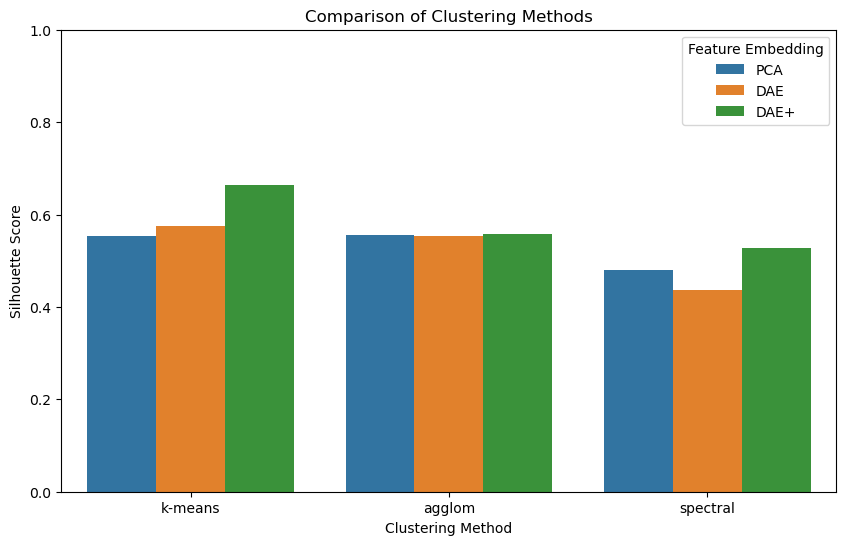

In [192]:
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster, y=silhouettes, hue=embedding)

# Customize the plot
plt.xlabel("Clustering Method")
plt.ylabel("Silhouette Score")
plt.title("Comparison of Clustering Methods")
plt.legend(title="Feature Embedding")
plt.ylim(0, 1)
plt.savefig("br_all_cluster_embedding_enh_comp.png", format="png")
plt.show()

## Epstein

In [195]:
ecv_pca_kmeans = m.silhouette_score(ecv_pca, ecv_results_df.loc["PCA_KMeans"].to_numpy(), metric='euclidean')

In [196]:
ecv_pca_agglom = m.silhouette_score(ecv_pca, ecv_results_df.loc["PCA_Agglom"].to_numpy(), metric='euclidean')

In [197]:
ecv_pca_spectral = m.silhouette_score(ecv_pca, ecv_results_df.loc["PCA_Spectral"].to_numpy(), metric='euclidean')

In [198]:
ecv_dae_kmeans = m.silhouette_score(ecv_dae, ecv_results_df.loc["DAE_KMeans"].to_numpy(), metric='euclidean')

In [199]:
ecv_dae_agglom = m.silhouette_score(ecv_dae, ecv_results_df.loc["DAE_Agglom"].to_numpy(), metric='euclidean')

In [200]:
ecv_dae_spectral = m.silhouette_score(ecv_dae, ecv_results_df.loc["DAE_Spectral"].to_numpy(), metric='euclidean')

In [201]:
ecv_daep_kmeans = m.silhouette_score(ecv_daep, ecv_results_df.loc["daep_KMeans"].to_numpy(), metric='euclidean')

In [202]:
ecv_daep_agglom = m.silhouette_score(ecv_daep, ecv_results_df.loc["daep_Agglom"].to_numpy(), metric='euclidean')

In [203]:
ecv_deap_spectral = m.silhouette_score(ecv_daep, ecv_results_df.loc["daep_Spectral"].to_numpy(), metric='euclidean')

In [204]:
embedding = ['PCA', 'PCA', 'PCA', 'DAE', 'DAE', 'DAE', 'DAE+', 'DAE+', 'DAE+']
cluster = ['k-means', 'agglom', 'spectral', 'k-means', 'agglom', 'spectral', 'k-means', 'agglom', 'spectral']
silhouettes = [ecv_pca_kmeans, ecv_pca_agglom, ecv_pca_spectral, ecv_dae_kmeans, ecv_dae_agglom, 
               ecv_dae_spectral, ecv_daep_kmeans, ecv_daep_agglom, ecv_deap_spectral]

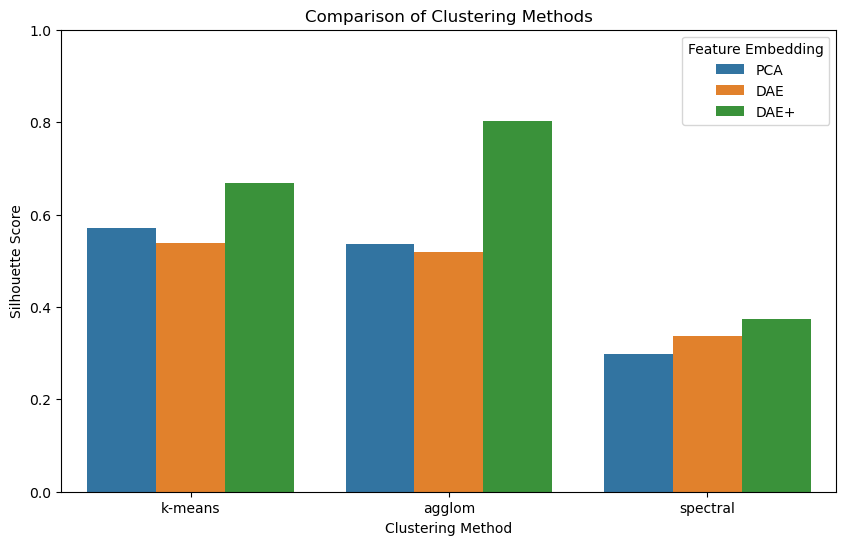

In [205]:
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster, y=silhouettes, hue=embedding)

# Customize the plot
plt.xlabel("Clustering Method")
plt.ylabel("Silhouette Score")
plt.title("Comparison of Clustering Methods")
plt.legend(title="Feature Embedding")
plt.ylim(0, 1)
plt.savefig("ecv_all_cluster_embedding_enh_comp.png", format="png")
plt.show()

## Forest Fire

In [208]:
ff_pca_kmeans = m.silhouette_score(ff_pca, ff_results_df.loc["PCA_KMeans"].to_numpy(), metric='euclidean')

In [209]:
ff_pca_agglom = m.silhouette_score(ff_pca, ff_results_df.loc["PCA_Agglom"].to_numpy(), metric='euclidean')

In [210]:
ff_pca_spectral = m.silhouette_score(ff_pca, ff_results_df.loc["PCA_Spectral"].to_numpy(), metric='euclidean')

In [211]:
ff_dae_kmeans = m.silhouette_score(ff_dae, ff_results_df.loc["DAE_KMeans"].to_numpy(), metric='euclidean')

In [212]:
ff_dae_agglom = m.silhouette_score(ff_dae, ff_results_df.loc["DAE_Agglom"].to_numpy(), metric='euclidean')

In [213]:
ff_dae_spectral = m.silhouette_score(ff_dae, ff_results_df.loc["DAE_Spectral"].to_numpy(), metric='euclidean')

In [214]:
ff_daep_kmeans = m.silhouette_score(ff_daep, ff_results_df.loc["daep_KMeans"].to_numpy(), metric='euclidean')

In [215]:
ff_daep_agglom = m.silhouette_score(ff_daep, ff_results_df.loc["daep_Agglom"].to_numpy(), metric='euclidean')

In [216]:
ff_deap_spectral = m.silhouette_score(ff_daep, ff_results_df.loc["daep_Spectral"].to_numpy(), metric='euclidean')

In [217]:
embedding = ['PCA', 'PCA', 'PCA', 'DAE', 'DAE', 'DAE', 'DAE+', 'DAE+', 'DAE+']
cluster = ['k-means', 'agglom', 'spectral', 'k-means', 'agglom', 'spectral', 'k-means', 'agglom', 'spectral']
silhouettes = [ff_pca_kmeans, ff_pca_agglom, ff_pca_spectral, ff_dae_kmeans, ff_dae_agglom, 
               ff_dae_spectral, ff_daep_kmeans, ff_daep_agglom, ff_deap_spectral]

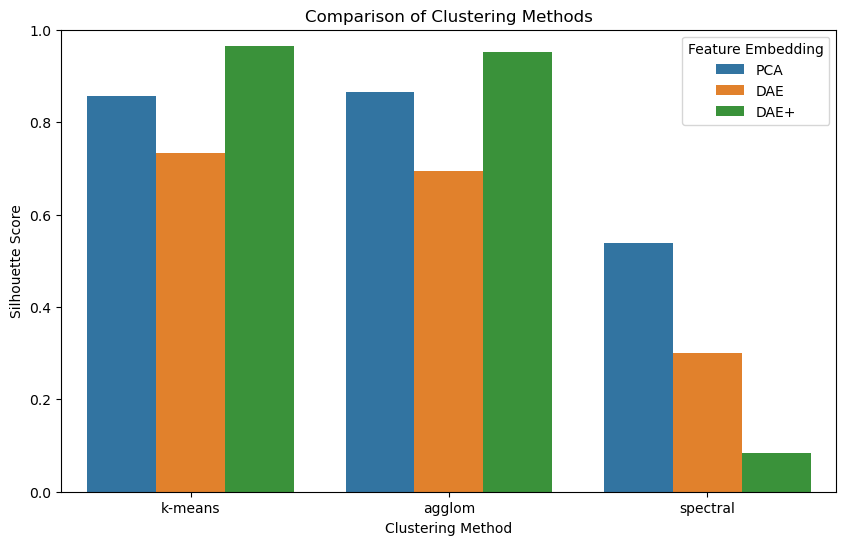

In [218]:
plt.figure(figsize=(10, 6))
sns.barplot(x=cluster, y=silhouettes, hue=embedding)

# Customize the plot
plt.xlabel("Clustering Method")
plt.ylabel("Silhouette Score")
plt.title("Comparison of Clustering Methods")
plt.legend(title="Feature Embedding")
plt.ylim(0, 1)
plt.savefig("ff_all_cluster_embedding_enh_comp.png", format="png")
plt.show()